In [86]:
import matplotlib.pyplot as plt
import matplotlib
from functools import partial
import numpy as np
import pickle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers

'''
col = (3.5,3.5)
col_margins = {'top':0.98,'right':0.98,'left':.2,'bottom':.15}
wide = (7.5,3.5)
wide_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.15}
full = (7.5,6)
full_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.1}
'''

matplotlib.rcParams.update({'font.size': 11})
matplotlib.rcParams.update({'axes.grid':True})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.fontsize':'small'})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'legend.fancybox':False})
matplotlib.rcParams.update({'legend.framealpha':0.6})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
RAM_MB = 8 *1024
x = np.arange(1,64*2)
y = np.arange(1,30)
T_grid, N_grid = np.meshgrid(x, y)

Coadded maps


In [2]:
file_perfs = 'fits_and_hdf5/namap_perf_profiling_coadded_maps.p'
perfs = pickle.load( open(file_perfs, 'rb'))

[0.037067, 0.037861, 0.038524, 0.039411, 0.040087, 0.040829, 0.041502, 0.04214, 0.042716, 0.044513, 0.04655]
[0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472]


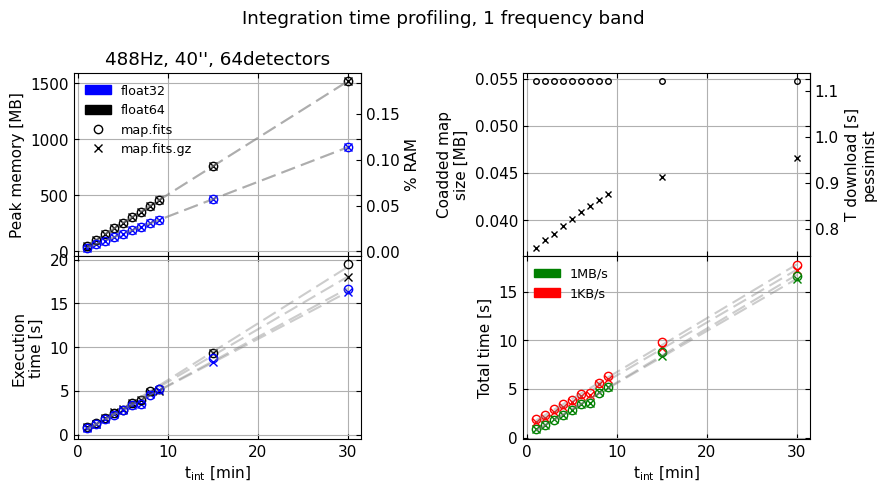

In [4]:
fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True)#,gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle("Integration time profiling, 1 frequency band")
axm, axb, axt, axT = axs[0,0], axs[0,1], axs[1,0], axs[1,1], 
key = 'profiling vs tod time'
key2 = "t_int"

for map_compression, marker in zip(('coadd.fits.gz', 'coadd.fits'), ('x','o')):
    axb.plot(perfs[key][key2], perfs[key]['float64'][map_compression]['output size [MB]'], marker,mfc='none',mec='k', markersize=4)
    print(perfs[key]['float64'][map_compression]['output size [MB]'])

    for precision, color in zip(('float64', 'float32'),('k','b','r')): 
        axm.plot(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

        axt.plot(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'],f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, colort, label in zip((0.048828125, 1), ('r','g'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key]['float32'][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key]['float32'][map_compression]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,f'{marker}', mfc='none',mec=colort, label=label)


        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
patch = mlines.Line2D([], [], linestyle='None',marker='o',    markerfacecolor='none',  markeredgecolor='k',  label='map.fits'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='map.fits.gz'); patchs.append(patch)
axm.legend(handles=patchs)

patchs = []
patch = mpatches.Patch(color='g', label='1MB/s'); patchs.append(patch); 
patch = mpatches.Patch(color='r', label='1KB/s'); patchs.append(patch); 
axT.legend(handles=patchs)


def f_to_z(x): return x/ (8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axT.set_ylabel('Total time [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axT.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

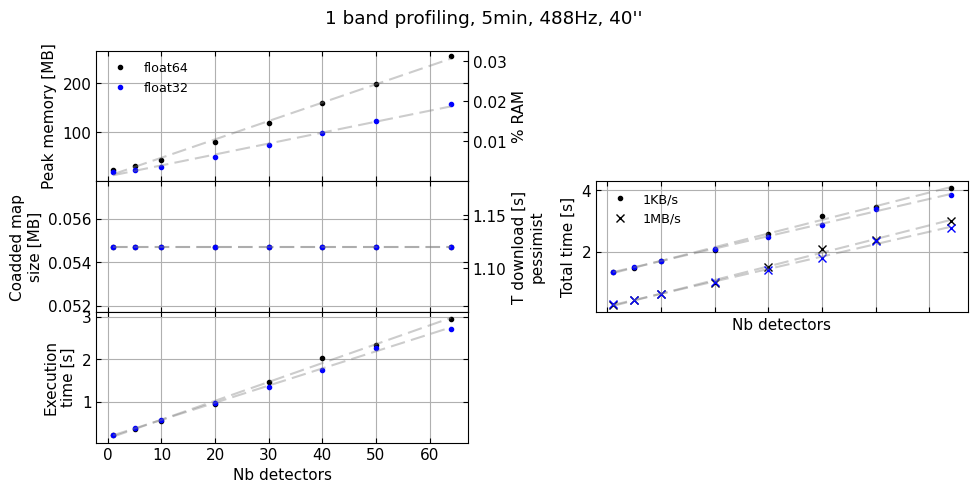

In [5]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[1,1]
axs[2,1].axis('off')
axs[0,1].axis('off')
key = 'profiling vs nb of detectors'
key2 = "nb detectors"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
    
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')


    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
    

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        
        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)

patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
axT.legend(handles=patchs)

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("1 band profiling, 5min, 488Hz, 40''")
axt.set_xlabel("Nb detectors")
axb.set_ylabel('Coadded map\nsize [MB]')
axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb detectors")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

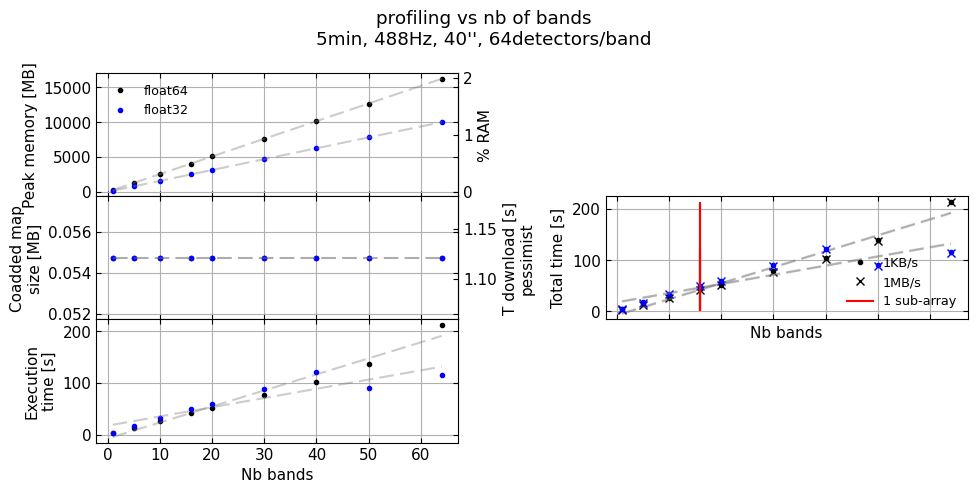

In [6]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[1,1]
axs[2,1].axis('off')
axs[0,1].axis('off')

key = 'profiling vs nb bands'
key2 = "nb bands"

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
        axT.vlines(16, 0, Ttot.max(), color='r')


patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)



patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='r', linestyle='solid',label='1 sub-array'); patchs.append(patch)

axT.legend(handles=patchs, loc= 'lower right')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("profiling vs nb of bands\n5min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axb.set_ylabel('Coadded map\nsize [MB]')

axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb bands")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

/tmp/ipykernel_28352/742553431.py:40: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',


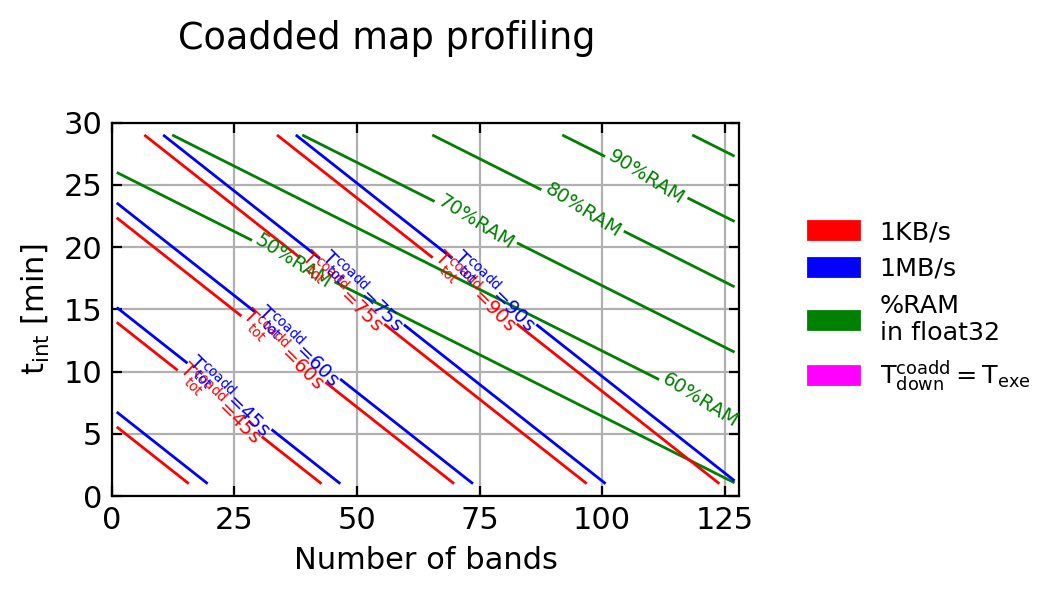

In [7]:


patchs = []
fig, ax = plt.subplots(figsize=(8/2,6/2), dpi=200)
ax.set_xlim(0,64*2)
ax.set_xlabel('Number of bands')
ax.set_ylim(0,30)
ax.set_ylabel('$\\rm t_{int}$ [min]')


#------------------------------
key = 'profiling vs nb bands'
key2 = "nb bands"
precision='float32'
peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_band, b_band = coeffs
#------------------------------

#------------------------------
key = 'profiling vs tod time'
key2 = "t_int"
map_compression = 'coadd.fits'
peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_tint, b_tint = coeffs
#------------------------------

peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)
'''
im = ax.imshow(peak_mem_tot, cmap='binary')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Peak Memory [%]')
'''
levels = (0.5,0.6,0.7, 0.8, 0.9, 1)  # 6 contour levels
CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',
                extent=[x.min(), x.max(), y.min(), y.max()])
ax.clabel(CS, inline=True, fmt=lambda v: f"{v*100:.0f}%RAM", fontsize=7, colors='g')


for telemetry, colort, label in zip((0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):

    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_band, b_band = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'coadd.fits'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_tint, b_tint = coeffs

    Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
    
    '''
    im = ax.imshow(Ttot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('$\\rm T_{tot}$ [min]')
    '''
    # --- Add constant Ttot lines
    levels = np.asarray((15,30,45,60,75,90))/60  # 6 contour levels
    CS = ax.contour(Ttot, levels=levels, colors=colort, linewidths=1.0,
                    extent=[x.min(), x.max(), y.min(), y.max()])
    ax.clabel(CS, inline=True, fmt=lambda v: "$\\rm T^{coadd}_{tot}$="+f"{v*60:.0f}s", fontsize=7, colors=colort)
    patch = mpatches.Patch(color=colort, label=label); patchs.append(patch); 
    #------------------------------

    #------------------------------
    
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    coeffs = np.polyfit(perfs[key][key2], telemetry_time, 1)
    a_band_telemetry, b_band_telemetry = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'coadd.fits'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    coeffs = np.polyfit(perfs[key][key2], telemetry_time, 1)
    a_tint_telemetry, b_tint_telemetry = coeffs

    #------------------------------
    
    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    execution_time = np.asarray(perfs[key][precision]['time [s]'])
    coeffs = np.polyfit(perfs[key][key2], execution_time, 1)
    a_band_execution, b_band_execution = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'coadd.fits'
    execution_time =  np.asarray(perfs[key][precision][map_compression]['time [s]'])
    coeffs = np.polyfit(perfs[key][key2], execution_time, 1)
    a_tint_execution, b_tint_execution = coeffs

    # Compute y where execution_time_tot = telemetry_time_tot
    delta_a_tint = a_tint_execution - a_tint_telemetry
    delta_a_band = a_band_execution - a_band_telemetry
    delta_b_tint = b_tint_execution - b_tint_telemetry
    delta_b_band = b_band_execution - b_band_telemetry

    y_boundary = -(delta_a_band * x + delta_b_tint + delta_b_band) / delta_a_tint
    ax.plot(x, y_boundary, 'magenta',  label='execution = telemetry')   
    #------------------------------
    
fig.suptitle('Coadded map profiling')

fig.tight_layout()
patch = mpatches.Patch(color='g', label='%RAM\nin float32'); patchs.append(patch); 
patch = mpatches.Patch(color='magenta', label='$\\rm T^{coadd}_{down}=T_{exe}$'); patchs.append(patch); 

ax.legend(handles=patchs, bbox_to_anchor = (1.5,0.8))


In [12]:
file_perfs = 'fits_and_hdf5/namap_perf_profiling_individual_maps.p'
perfs = pickle.load( open(file_perfs, 'rb'))

[0.10948371887207031, 0.11038684844970703, 0.11109542846679688, 0.11199760437011719, 0.11273765563964844, 0.11344718933105469, 0.11413288116455078, 0.11484527587890625, 0.1155538558959961, 0.12015342712402344, 0.13215160369873047]
[3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375]


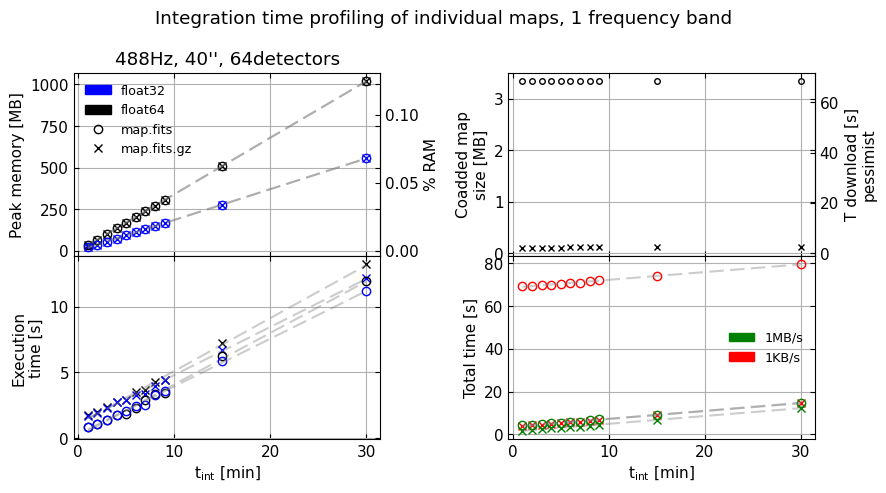

In [14]:
fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True)#,gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle("Integration time profiling of individual maps, 1 frequency band")
axm, axb, axt, axT = axs[0,0], axs[0,1], axs[1,0], axs[1,1], 
key = 'profiling vs tod time'
key2 = "t_int"

for map_compression, marker in zip(('individual.fits.gz', 'individual.fits'), ('x','o')):
    axb.plot(perfs[key][key2], perfs[key]['float64'][map_compression]['output size [MB]'], marker,mfc='none',mec='k', markersize=4)
    print(perfs[key]['float64'][map_compression]['output size [MB]'])

    for precision, color in zip(('float64', 'float32'),('k','b','r')): 
        axm.plot(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

        axt.plot(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'],f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, colort, label in zip((0.048828125, 1), ('r','g'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key]['float32'][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key]['float32'][map_compression]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,f'{marker}', mfc='none',mec=colort, label=label)


        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
patch = mlines.Line2D([], [], linestyle='None',marker='o',    markerfacecolor='none',  markeredgecolor='k',  label='map.fits'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='map.fits.gz'); patchs.append(patch)
axm.legend(handles=patchs)

patchs = []
patch = mpatches.Patch(color='g', label='1MB/s'); patchs.append(patch); 
patch = mpatches.Patch(color='r', label='1KB/s'); patchs.append(patch); 
axT.legend(handles=patchs)

def f_to_z(x): return x/ (8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axT.set_ylabel('Total time [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axT.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

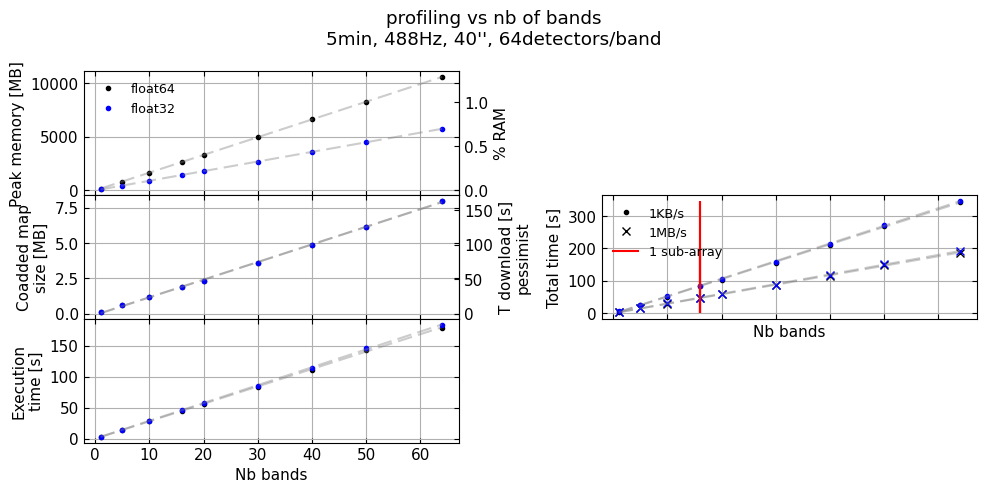

In [17]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[1,1]
axs[2,1].axis('off')
axs[0,1].axis('off')

key = 'profiling vs nb bands'
key2 = "nb bands"

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
        axT.vlines(16, 0, Ttot.max(), color='r')


patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)



patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='r', linestyle='solid',label='1 sub-array'); patchs.append(patch)

axT.legend(handles=patchs, loc= 'upper left')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("profiling vs nb of bands\n5min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axb.set_ylabel('Coadded map\nsize [MB]')

axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb bands")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

/tmp/ipykernel_28352/3513217545.py:35: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',


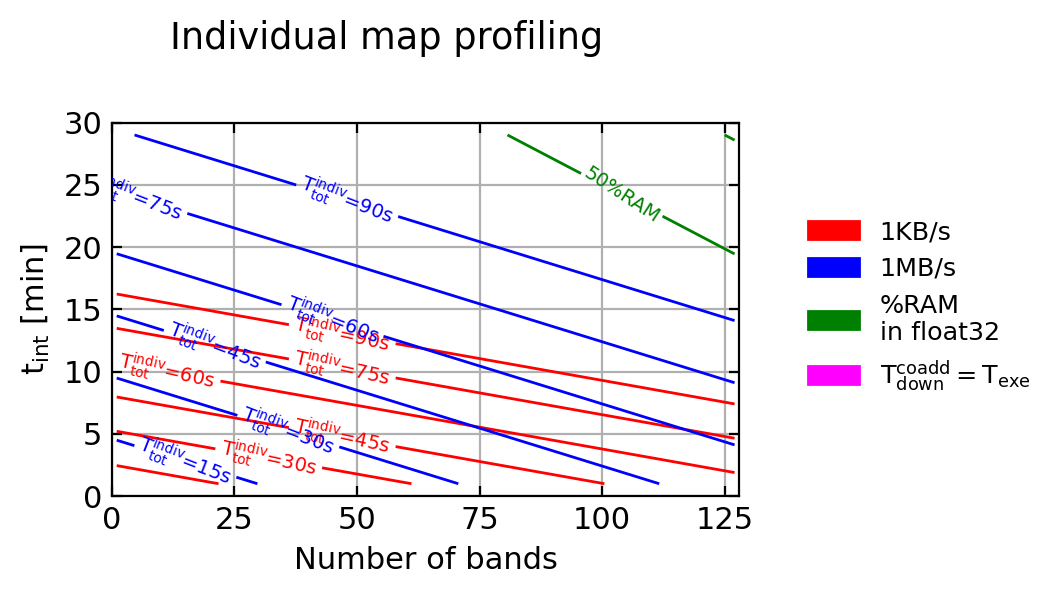

In [21]:
patchs = []
fig, ax = plt.subplots(figsize=(8/2,6/2), dpi=200)
ax.set_xlim(0,64*2)
ax.set_xlabel('Number of bands')
ax.set_ylim(0,30)
ax.set_ylabel('$\\rm t_{int}$ [min]')

#------------------------------
key = 'profiling vs nb bands'
key2 = "nb bands"
precision='float32'
peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_band, b_band = coeffs
#------------------------------

#------------------------------
key = 'profiling vs tod time'
key2 = "t_int"
map_compression = 'individual.fits.gz'
peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_tint, b_tint = coeffs
#------------------------------

peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)
'''
im = ax.imshow(peak_mem_tot, cmap='binary')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Peak Memory [%]')
'''
levels = (0.5,0.6,0.7, 0.8, 0.9, 1)  # 6 contour levels
CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',
                extent=[x.min(), x.max(), y.min(), y.max()])
ax.clabel(CS, inline=True, fmt=lambda v: f"{v*100:.0f}%RAM", fontsize=7, colors='g')

for telemetry, colort, label in zip((0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):

    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_band, b_band = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'individual.fits.gz'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_tint, b_tint = coeffs

    Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
    
    '''
    im = ax.imshow(Ttot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('$\\rm T_{tot}$ [min]')
    '''
    # --- Add constant Ttot lines
    levels = np.asarray((15,30,45,60,75,90))/60  # 6 contour levels
    CS = ax.contour(Ttot, levels=levels, colors=colort, linewidths=1.0,
                    extent=[x.min(), x.max(), y.min(), y.max()])
    ax.clabel(CS, inline=True, fmt=lambda v: "$\\rm T^{indiv}_{tot}$="+f"{v*60:.0f}s", fontsize=7, colors=colort)
    patch = mpatches.Patch(color=colort, label=label); patchs.append(patch); 
    #------------------------------

    #------------------------------
    
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    coeffs = np.polyfit(perfs[key][key2], telemetry_time, 1)
    a_band_telemetry, b_band_telemetry = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'individual.fits.gz'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    coeffs = np.polyfit(perfs[key][key2], telemetry_time, 1)
    a_tint_telemetry, b_tint_telemetry = coeffs

    #------------------------------
    
    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    execution_time = np.asarray(perfs[key][precision]['time [s]'])
    coeffs = np.polyfit(perfs[key][key2], execution_time, 1)
    a_band_execution, b_band_execution = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'individual.fits.gz'
    execution_time =  np.asarray(perfs[key][precision][map_compression]['time [s]'])
    coeffs = np.polyfit(perfs[key][key2], execution_time, 1)
    a_tint_execution, b_tint_execution = coeffs

    # Compute y where execution_time_tot = telemetry_time_tot
    delta_a_tint = a_tint_execution - a_tint_telemetry
    delta_a_band = a_band_execution - a_band_telemetry
    delta_b_tint = b_tint_execution - b_tint_telemetry
    delta_b_band = b_band_execution - b_band_telemetry

    y_boundary = -(delta_a_band * x + delta_b_tint + delta_b_band) / delta_a_tint
    ax.plot(x, y_boundary, 'magenta',  label='execution = telemetry')   
    #------------------------------
    
fig.suptitle('Individual map profiling')

fig.tight_layout()
patch = mpatches.Patch(color='g', label='%RAM\nin float32'); patchs.append(patch); 
patch = mpatches.Patch(color='magenta', label='$\\rm T^{coadd}_{down}=T_{exe}$'); patchs.append(patch); 

ax.legend(handles=patchs, bbox_to_anchor = (1.5,0.8))


/tmp/ipykernel_28352/2409720637.py:48: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(peak_mem_tot, levels=levels, colors=color, linewidths=1.0,linestyle = ':',


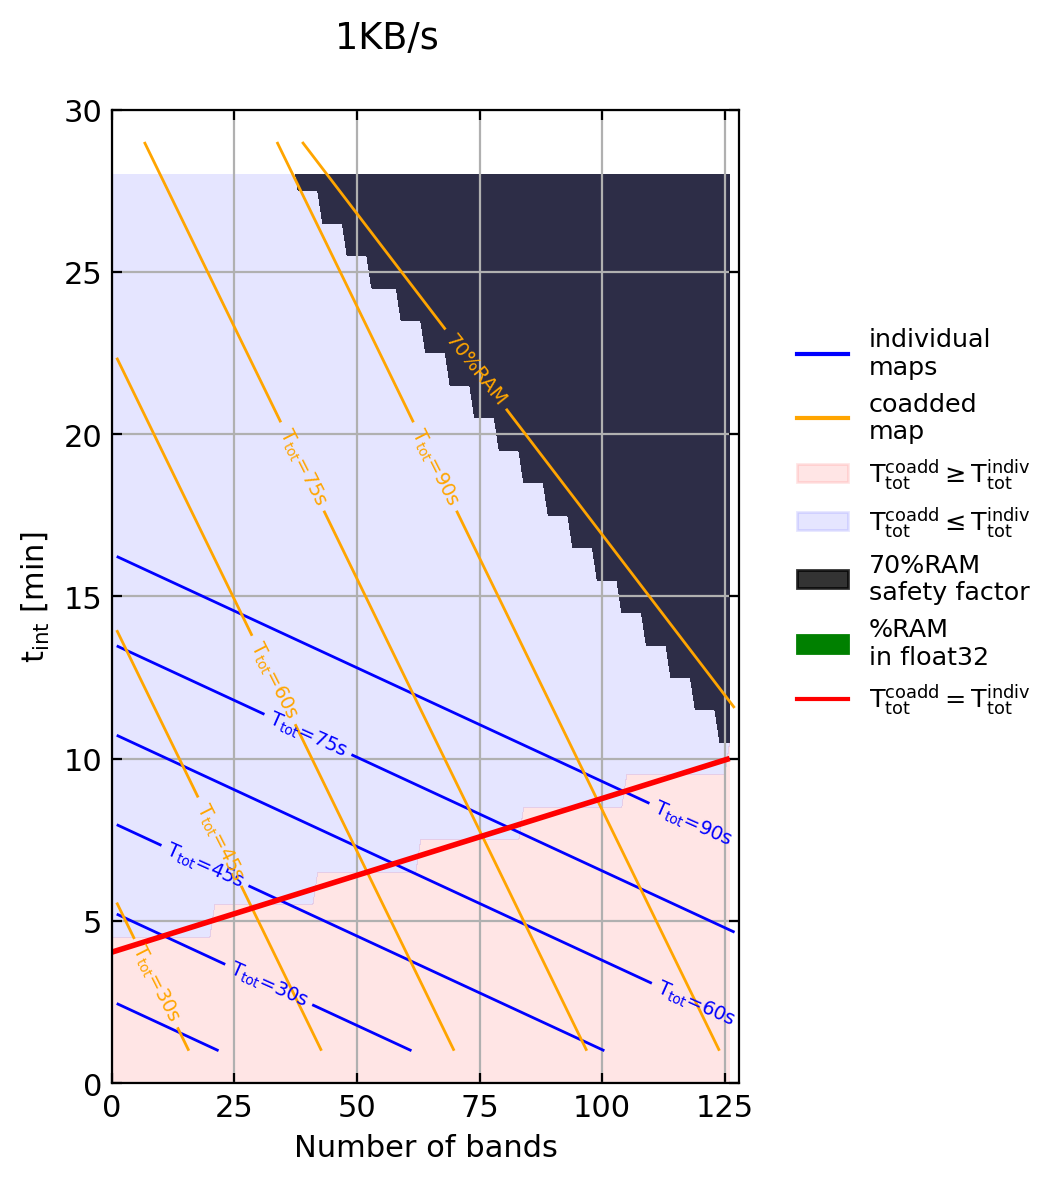

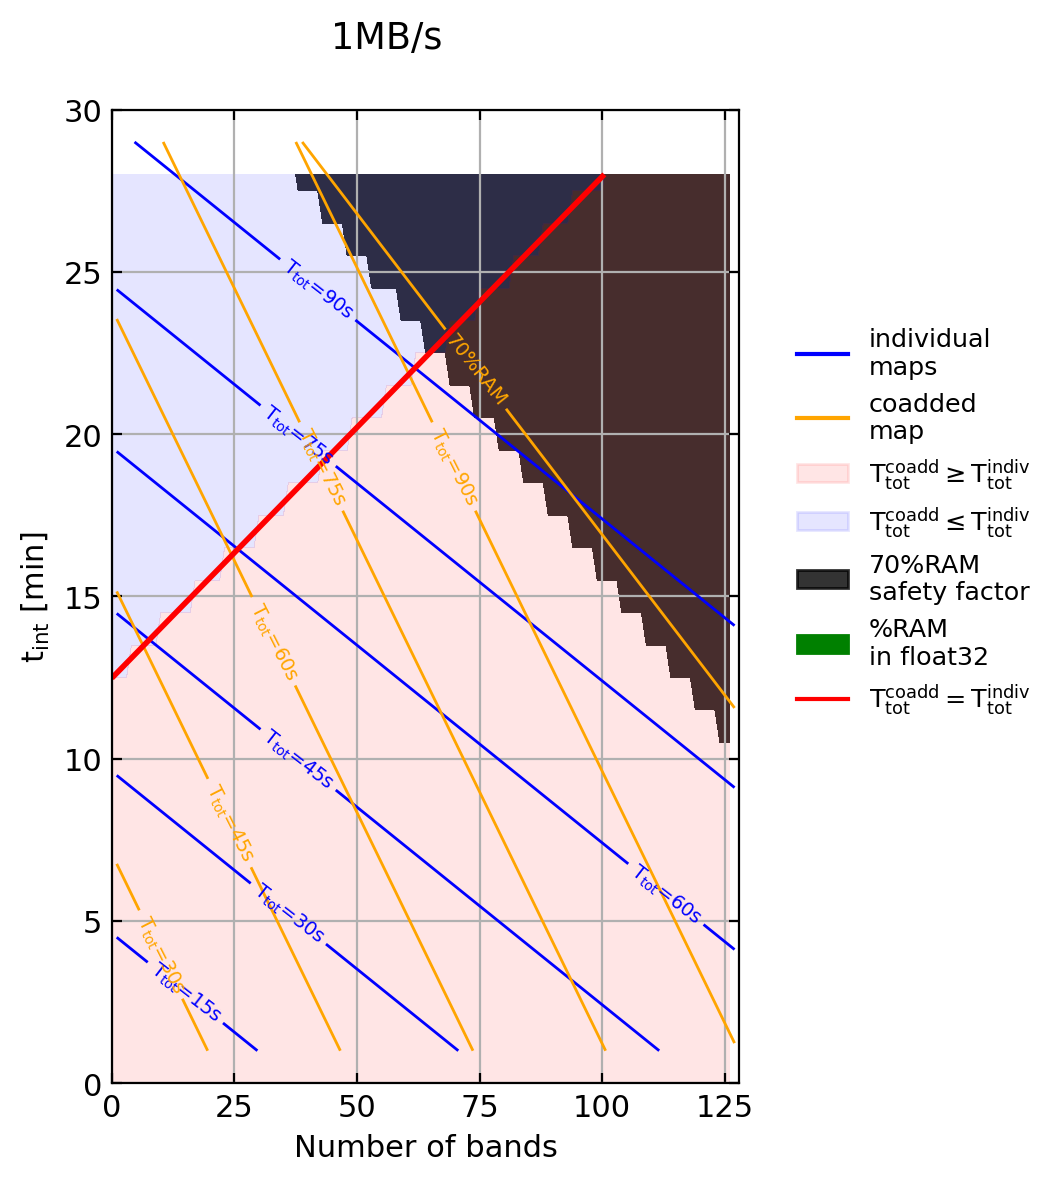

In [87]:
for telemetry, colort, label_telemetry in zip((0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):
    patchs = []
    fig, ax = plt.subplots(figsize=(8/2,12/2), dpi=200)
    ax.set_xlim(0,64*2)
    ax.set_xlabel('Number of bands')
    ax.set_ylim(0,30)
    ax.set_ylabel('$\\rm t_{int}$ [min]')

    linear_params_list = np.zeros((2,4))
    Ttot_list = []
        
    for i, (dictfile, map_compression, color, label) in enumerate(zip(('fits_and_hdf5/namap_perf_profiling_individual_maps.p',
                                                                       'fits_and_hdf5/namap_perf_profiling_coadded_maps.p'),
                                                ('individual.fits.gz','coadd.fits'), ('b','orange'), ('individual\nmaps','coadded\nmap'))): 
        
        perfs = pickle.load( open(dictfile, 'rb'))
        patch = mlines.Line2D([], [], color=color, linestyle='solid',label=label); patchs.append(patch)

        #------------------------------
        key = 'profiling vs nb bands'
        key2 = "nb bands"
        precision='float32'
        peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
        coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
        a_band, b_band = coeffs
        #------------------------------

        #------------------------------
        key = 'profiling vs tod time'
        key2 = "t_int"
        peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
        coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
        a_tint, b_tint = coeffs
        #------------------------------

        peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)
        '''
        im = ax.imshow(peak_mem_tot, cmap='binary')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Peak Memory [%]')
        '''


        levels = (0.7,)  # 6 contour levels
                # Compute the shaded region first
        CS = ax.contour(peak_mem_tot, levels=levels, colors=color, linewidths=1.0,linestyle = ':',
                        extent=[x.min(), x.max(), y.min(), y.max()])
        ax.contourf(peak_mem_tot > levels[0], levels=[0.5, 1.5], colors=['k'], alpha=0.8)
        ax.clabel(CS, inline=True, fmt=lambda v: f"{v*100:.0f}%RAM", fontsize=7, colors=color)
        

        #------------------------------
        key = 'profiling vs nb bands'
        key2 = "nb bands"
        precision='float32'

        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
        coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        a_band, b_band = coeffs
        linear_params_list[i,2] = a_tint
        linear_params_list[i,3] = b_tint

        key = 'profiling vs tod time'
        key2 = "t_int"
        telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
        coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        a_tint, b_tint = coeffs

        linear_params_list[i,0] = a_band
        linear_params_list[i,1] = b_band

        Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
        Ttot_list.append(Ttot)
        
        '''
        im = ax.imshow(Ttot)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('$\\rm T_{tot}$ [min]')
        '''
        # --- Add constant Ttot lines
        levels = np.asarray((15,30,45,60,75,90))/60  # 6 contour levels
        CS = ax.contour(Ttot, levels=levels, colors=color, linewidths=1.0,
                        extent=[x.min(), x.max(), y.min(), y.max()])
        ax.clabel(CS, inline=True, fmt=lambda v: "$\\rm T_{tot}$="+f"{v*60:.0f}s", fontsize=7, colors=color)
        #------------------------------

        
    # Compute the difference field
    diff = np.diff(np.asarray(Ttot_list), axis=0)[0] #indiv-coadde
    contour = ax.contour(diff, levels=[0], colors='r', linewidths=2)

    ax.contourf(diff > 0, levels=[0.5, 1.5], colors=['red'], alpha=0.1)
    ax.contourf(diff < 0, levels=[0.5, 1.5], colors=['blue'], alpha=0.1)

    '''
    im = ax.imshow(diff,cmap='binary')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('$\\rm T_{tot}$ [min]')
    '''

    '''
    delta_params = np.diff(linear_params_list, axis=0)
    y_boundary = -(delta_params[0][2] * x + delta_params[0][1] + delta_params[0][3]) / delta_params[0][0]
    ax.plot(x, y_boundary, 'r', lw=2, label='execution = telemetry')
    '''
    fig.suptitle(f'{label_telemetry}')
    fig.tight_layout()
    patch = mpatches.Patch(color='r',  alpha=0.1,label='$\\rm T^{coadd}_{tot} \geq T^{indiv}_{tot}$'); patchs.append(patch); 
    patch = mpatches.Patch(color='b',  alpha=0.1,label='$\\rm T^{coadd}_{tot} \leq T^{indiv}_{tot}$'); patchs.append(patch); 
    patch = mpatches.Patch(color='k',  alpha=0.8,label='70%RAM\nsafety factor'); patchs.append(patch); 
    patch = mpatches.Patch(color='g', label='%RAM\nin float32'); patchs.append(patch); 

    patch = mlines.Line2D([], [], color='r', linestyle='solid',label='$\\rm T^{coadd}_{tot} = T^{indiv}_{tot}$'); patchs.append(patch)


    ax.legend(handles=patchs, bbox_to_anchor = (1.5,0.8))
        


KeyError: 'profiling vs resolution'

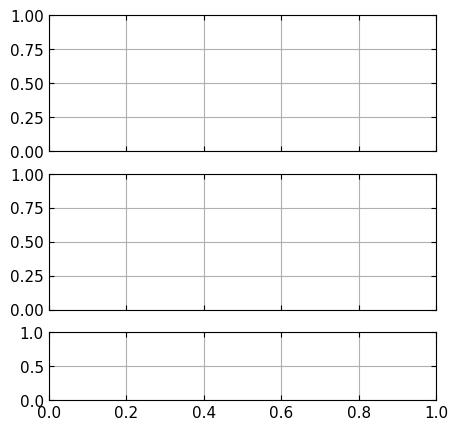

In [15]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs resolution'
key2 = "resolution ['']"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}')
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}', label= precision)
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')


def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')


def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')


ymin, ymax = axm.get_ylim()
axb.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title('3min, 488Hz, 64 detectors')
axt.set_xlabel("Resolution ['']")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

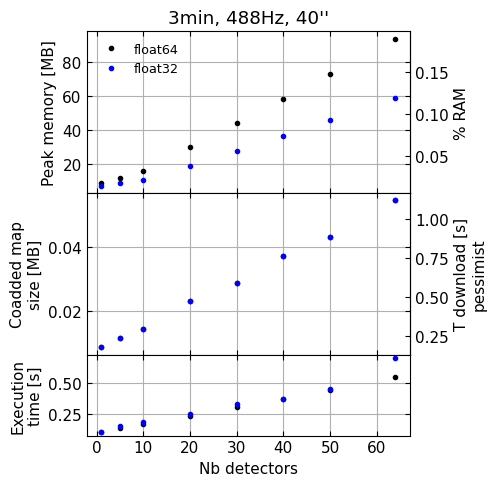

In [5]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs nb of detectors'
key2 = "nb detectors"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')


def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("3min, 488Hz, 40''")
axt.set_xlabel("Nb detectors")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

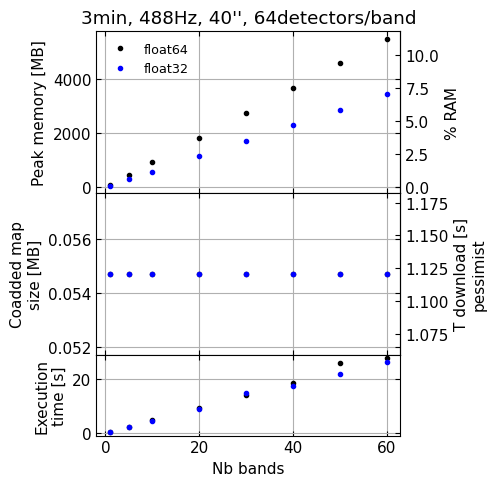

In [6]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs nb bands'
key2 = "nb bands"

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')


for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("3min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

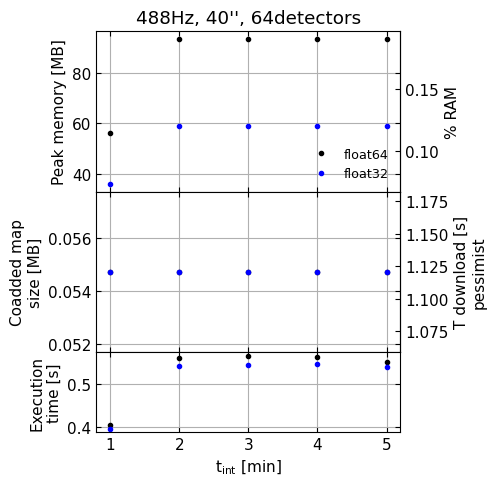

In [7]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs tod time'
key2 = "t_int"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')


def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')


ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

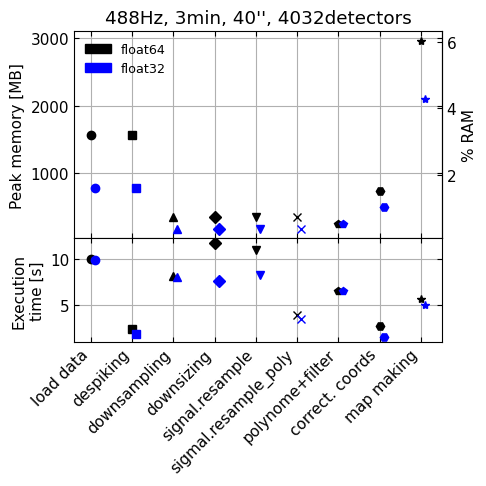

In [8]:
fig, (axm, axt) = plt.subplots(2,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2,  1]})
key = 'profiling fcts'
fcts_list = ('loaddata','despiking','zoom_sync', 'zoom_sync_v2', 'zoom_sync_v3','zoom_sync_v4','polynome_fft_filter','correct_coords','map_making')
fcts_list_name = ('load data','despiking','downsampling', 'downsizing', 'signal.resample','sigmal.resample_poly','polynome+filter','correct. coords','map making')

patchs = []
for ip, (precision, color) in enumerate(zip(('float64', 'float32'),('k','b','r'))): 
    patch = mpatches.Patch(color=color, label= precision); patchs.append(patch); 

    for fi, (fct, m) in enumerate(zip(fcts_list,('o', 's', '^', 'D', 'v', 'x', 'p', 'H','*'))):

        #if(color=='b'): patch = mlines.Line2D([], [], color='k', linestyle='None',marker=m,  label=fct); patchs.append(patch)
        axm.plot((fi+1+0.1*ip), perfs[key][precision][fct]['peak memory [MB]'], color=f'{color}', marker = m)
        axt.plot((fi+1+0.1*ip), perfs[key][precision][fct]['time [s]'], color=f'{color}', marker = m)

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

ymin, ymax = axm.get_ylim()
axm.legend(handles=patchs)
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("488Hz, 3min, 40'', 4032detectors")

axt.set_xticks(range(1, len(fcts_list)+1))
axt.set_xticklabels(fcts_list_name, rotation=45, ha='right')


fig.tight_layout()
fig.subplots_adjust(hspace=0)

In [16]:
dict2['size'][:,2,1,1]

array([0.308598, 0.328294, 0.351288, 0.351288, 0.40824 , 0.46539 ,
       0.384704, 0.483542, 0.580933, 0.483542, 0.671512, 0.875318,
       0.671512, 1.060366, 1.428468, 0.762944, 1.268382, 1.728287,
       0.875318, 1.428468, 2.034422, 1.49181 , 2.690621, 3.882933])

In [28]:
dict2 =  pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/tod_profiling_vs_nb_dets.p', 'rb'))
#dict1 =  pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/tod_profiling.p', 'rb'))

d={}
for j, f in enumerate(dict2['data_freq']):
    for k, b in enumerate(dict2['format']): 
        d[f'{f:.0f}Hz_{b}bit'] = {}
        d[f'{f:.0f}Hz_{b}bit']['num_detectors'] = dict2['nb dets']
        d[f'{f:.0f}Hz_{b}bit']['weights_mb']    = dict2['size'][:,2,j,k]
for j, f in enumerate(dict2['data_freq']):
    d[f'_{f:.0f}Hz_16bit'] = {}
    d[f'_{f:.0f}Hz_16bit']['num_detectors'] = dict2['nb dets']
    for i, t in enumerate(dict2['time [min]']): 
        d[f'_{f:.0f}Hz_16bit'][f'{t}min weights_mb'] = dict2['size'][:,i,j,1]
        
times = dict2['time [min]']

KeyError: '488Hz_64bit'

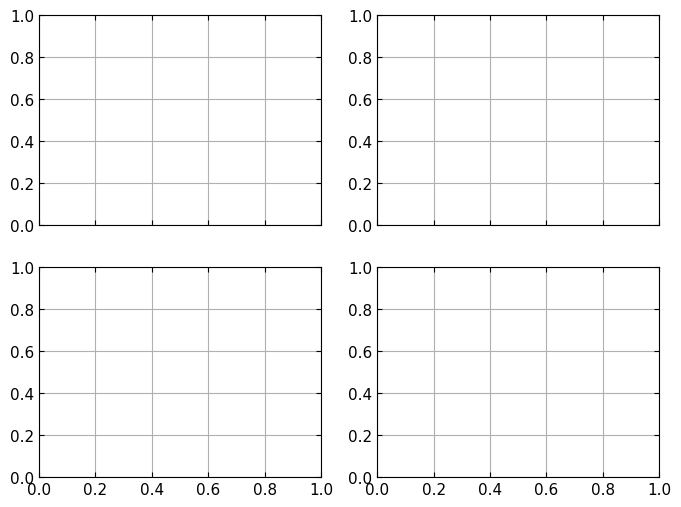

In [18]:
fig, axs = plt.subplots(2,2,figsize=(8,6), sharex=True)

for it, (t, l) in enumerate(zip((20,0.0488*60), ('s', 'min'))):
    for fi, f in enumerate(('488','100')):
        for b,c in zip(('64','32','16'), ('k', 'b','r')):
            axs[it,fi].plot(d[f'{f}Hz_{b}bit']['num_detectors'], d[f'{f}Hz_{b}bit']['weights_mb'], f'.{c}', label=f'{b}B')
        axs[0,0].legend()
        axs[1,fi].set_xlabel('nb detectors')
        axs[it,fi].set_ylabel('TOD.hdf5 size [MB]')
        axs[0,fi].set_title(f'{f}Hz')
        
        def f_to_z(x,telemetry,): return x/telemetry
        f_single = partial(f_to_z, telemetry=t)  # example value
        secax = axs[it,fi].secondary_yaxis("right", functions=(f_single,f_single))
        secax.set_ylabel(f'T download [{l}]')

fig.suptitle('2 minutes')
fig.tight_layout()
fig.subplots_adjust(hspace=0)


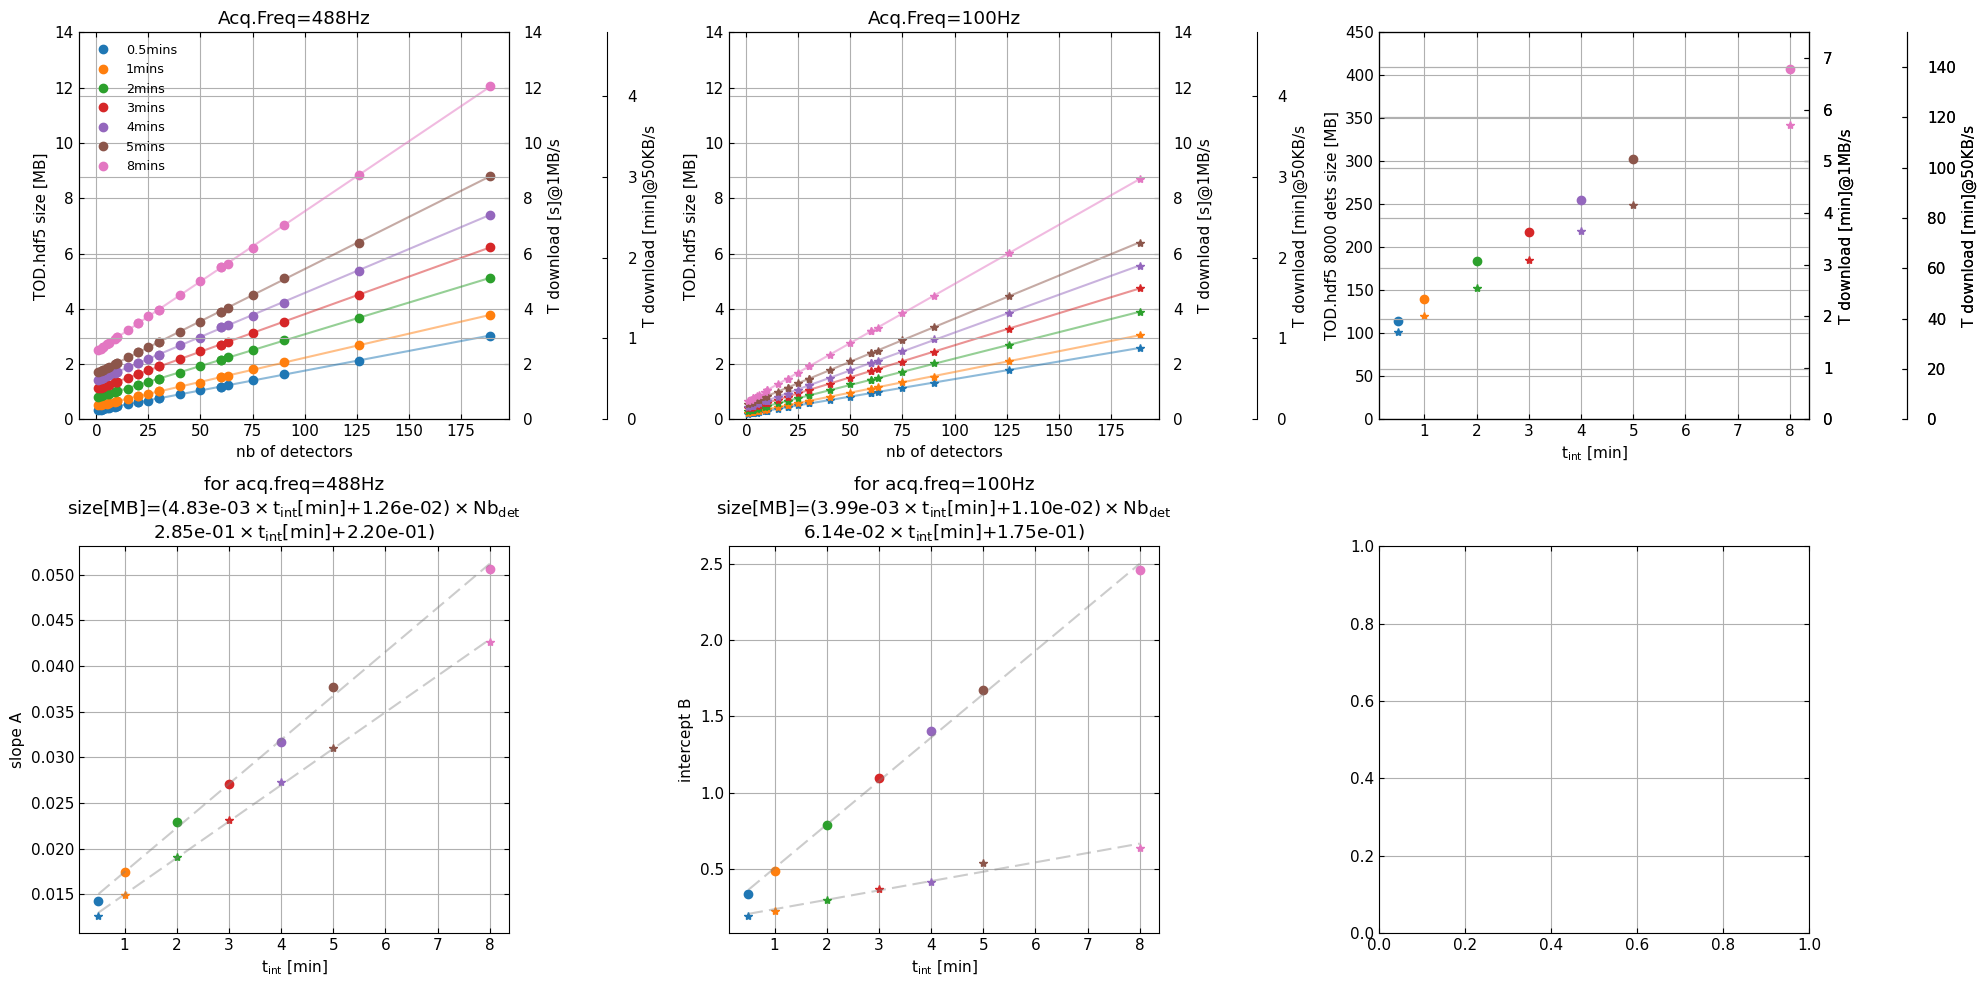

In [29]:
# Create 1x3 subplots
fig, axs = plt.subplots(2, 3, figsize=(20, 10), )

for fi, (f, m) in enumerate(zip(('488','100',), ('o', '*', ''))):
    a_list = []
    b_list = []

    for t, c in zip(times, ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink')):
        if(fi>1): continue
        x = d[f'_{f}Hz_16bit']['num_detectors']
        axs[0,fi].plot(x, d[f'_{f}Hz_16bit'][f'{t}min weights_mb'],m, c=c, label=f'{t}mins')

        coeffs = np.polyfit(x, d[f'_{f}Hz_16bit'][f'{t}min weights_mb'], 1)  # [slope, intercept]
        a, b = coeffs
        y_7000 = np.polyval(coeffs, 8000)
        x_fit = np.linspace(min(x), max(x), 200)
        y_fit = np.polyval(coeffs, x_fit)
        axs[0,fi].plot(x_fit, y_fit, color=c, alpha=0.5)
        axs[0,fi].set_title(f'Acq.Freq={f}Hz')
        axs[0,fi].set_xlabel('nb of detectors')
        axs[0,2].plot(t, y_7000,m,c=c, )
        axs[0,2].set_xlabel('$\\rm t_{int}$ [min]')
        axs[0,2].set_ylabel('TOD.hdf5 8000 dets size [MB]')
        axs[0,0].set_ylabel('TOD.hdf5 size [MB]')
        axs[0,1].set_ylabel('TOD.hdf5 size [MB]')

        axs[1,0].plot(t, a,m,c=c, )
        axs[1,0].set_xlabel('$\\rm t_{int}$ [min]')
        axs[1,0].set_ylabel('slope A')
        a_list.append(a)

        axs[1,1].plot(t, b,m,c=c, )
        axs[1,1].set_xlabel('$\\rm t_{int}$ [min]')
        axs[1,1].set_ylabel('intercept B')
        b_list.append(b)

    axs[0,fi].set_ylim(0,14)
    axs[0,2].set_ylim(0,450)



    a_coeffs = np.polyfit(times, np.asarray(a_list), 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(times), max(times), 200)
    y_lin = p_lin(x_fit)
    axs[1,0].plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)


    b_coeffs = np.polyfit(times, np.asarray(b_list), 1)
    p_lin = np.poly1d(b_coeffs)
    x_fit = np.linspace(min(times), max(times), 200)
    y_lin = p_lin(x_fit)
    axs[1,1].plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axs[1,fi].set_title(f'for acq.freq={f}Hz\nsize[MB]=({a_coeffs[0]:.2e}'+'$\\rm \\times t_{int}[min]$'+f'+{a_coeffs[1]:.2e})'+'$\\rm \\times Nb_{det}$\n'
                            +f'{b_coeffs[0]:.2e}'+'$\\rm \\times t_{int}[min]$'+f'+{b_coeffs[1]:.2e})')

    
    # ---------------------------
    # First right y-axis (secondary_yaxis)
    # ---------------------------

    def f_to_z(x,telemetry,): return x/telemetry
    f_single = partial(f_to_z, telemetry=1)  # example valux
    secax1 = axs[0,fi].secondary_yaxis("right", functions=(f_single,f_single))
    secax1.set_ylabel(f'T download [s]@1MB/s')
    secax1.tick_params(axis='y', pad=10, direction='in')

    # ---------------------------
    # Second right y-axis (twinx, shifted outward)
    # ---------------------------
    ax2 = axs[0,fi].twinx()
    telemetry_ax2 = 0.0488*60
    ax2.set_ylim(axs[0,fi].get_ylim()[0]/telemetry_ax2, axs[0,fi].get_ylim()[1]/telemetry_ax2)    # Shift outward by 60 points to the right, independent of subplot
    ax2.spines['right'].set_position(('outward', 70))
    ax2.set_ylabel(f'T download [min]@50KB/s')
    ax2.tick_params(axis='y', pad=15)

    #--

    def f_to_z(x,telemetry,): return x/telemetry
    f_single = partial(f_to_z, telemetry=1*60)  # example value
    secax1 = axs[0,2].secondary_yaxis("right", functions=(f_single,f_single))
    secax1.set_ylabel(f'T download [min]@1MB/s')
    secax1.tick_params(axis='y', pad=10, direction='in')

    # ---------------------------
    # Second right y-axis (twinx, shifted outward)
    # ---------------------------
    ax2 = axs[0,2].twinx()
    telemetry_ax2 = 0.0488*60
    ax2.set_ylim(axs[0,2].get_ylim()[0]/telemetry_ax2, axs[0,2].get_ylim()[1]/telemetry_ax2)    # Shift outward by 60 points to the right, independent of subplot
    ax2.spines['right'].set_position(('outward', 70))
    ax2.set_ylabel(f'T download [min]@50KB/s')
    ax2.tick_params(axis='y', pad=15)
    
    
# Add legend to the first subplot
axs[0,0].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [19]:
dict2 =  pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/tod_profiling_vs_nb_dets.p', 'rb'))
#dict1 =  pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/tod_profiling.p', 'rb'))

d={}
for j, f in enumerate(dict2['data_freq']):
    d[f'_{f:.0f}Hz_32bit'] = {}
    d[f'_{f:.0f}Hz_32bit']['num_detectors'] = dict2['nb dets']
    for i, t in enumerate(dict2['time [min]']): 
        d[f'_{f:.0f}Hz_32bit'][f'{t}min weights_mb'] = dict2['size'][:,i,j,0]
        
times = dict2['time [min]']

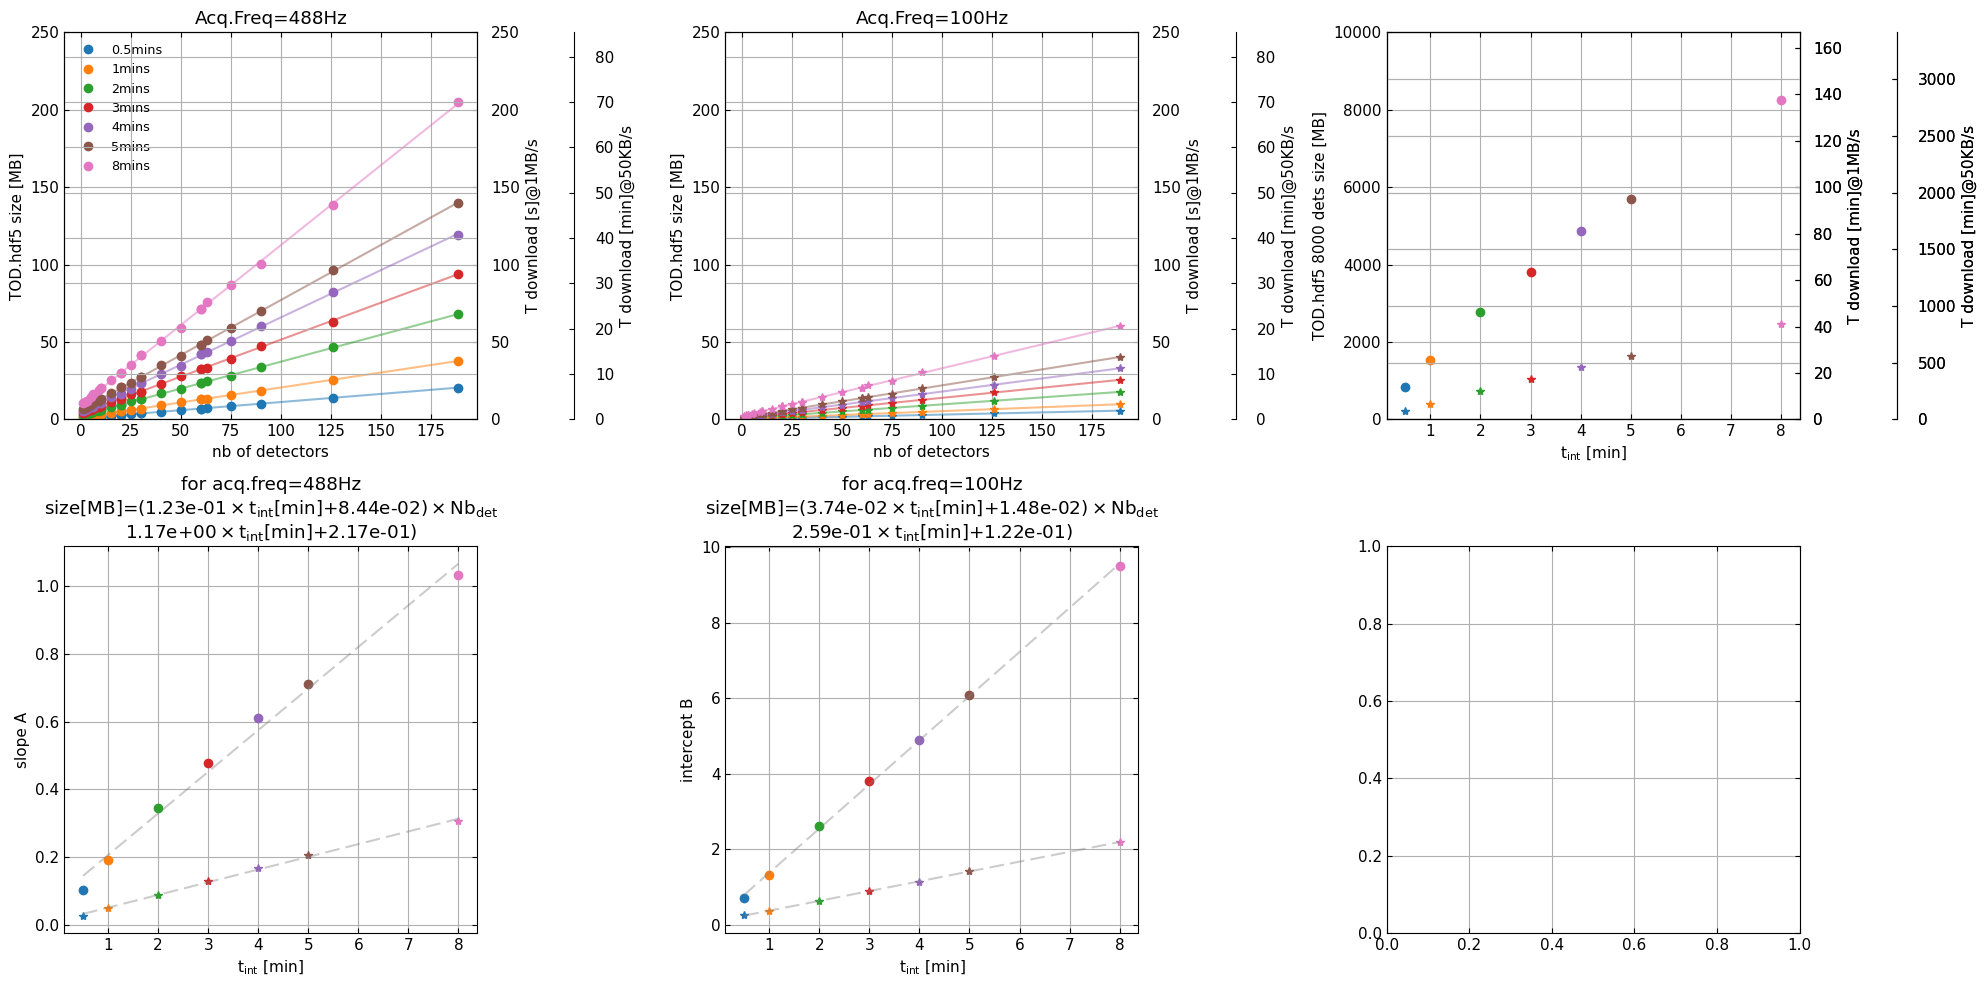

In [27]:
# Create 1x3 subplots
fig, axs = plt.subplots(2, 3, figsize=(20, 10), )

for fi, (f, m) in enumerate(zip(('488','100',), ('o', '*', ''))):
    a_list = []
    b_list = []

    for t, c in zip(times, ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink')):
        if(fi>1): continue
        x = d[f'_{f}Hz_32bit']['num_detectors']
        axs[0,fi].plot(x, d[f'_{f}Hz_32bit'][f'{t}min weights_mb'],m, c=c, label=f'{t}mins')

        coeffs = np.polyfit(x, d[f'_{f}Hz_32bit'][f'{t}min weights_mb'], 1)  # [slope, intercept]
        a, b = coeffs
        y_7000 = np.polyval(coeffs, 8000)
        x_fit = np.linspace(min(x), max(x), 200)
        y_fit = np.polyval(coeffs, x_fit)
        axs[0,fi].plot(x_fit, y_fit, color=c, alpha=0.5)
        axs[0,fi].set_title(f'Acq.Freq={f}Hz')
        axs[0,fi].set_xlabel('nb of detectors')
        axs[0,2].plot(t, y_7000,m,c=c, )
        axs[0,2].set_xlabel('$\\rm t_{int}$ [min]')
        axs[0,2].set_ylabel('TOD.hdf5 8000 dets size [MB]')
        axs[0,0].set_ylabel('TOD.hdf5 size [MB]')
        axs[0,1].set_ylabel('TOD.hdf5 size [MB]')

        axs[1,0].plot(t, a,m,c=c, )
        axs[1,0].set_xlabel('$\\rm t_{int}$ [min]')
        axs[1,0].set_ylabel('slope A')
        a_list.append(a)

        axs[1,1].plot(t, b,m,c=c, )
        axs[1,1].set_xlabel('$\\rm t_{int}$ [min]')
        axs[1,1].set_ylabel('intercept B')
        b_list.append(b)

    axs[0,fi].set_ylim(0,250)
    axs[0,2].set_ylim(0,1e4)



    a_coeffs = np.polyfit(times, np.asarray(a_list), 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(times), max(times), 200)
    y_lin = p_lin(x_fit)
    axs[1,0].plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)


    b_coeffs = np.polyfit(times, np.asarray(b_list), 1)
    p_lin = np.poly1d(b_coeffs)
    x_fit = np.linspace(min(times), max(times), 200)
    y_lin = p_lin(x_fit)
    axs[1,1].plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axs[1,fi].set_title(f'for acq.freq={f}Hz\nsize[MB]=({a_coeffs[0]:.2e}'+'$\\rm \\times t_{int}[min]$'+f'+{a_coeffs[1]:.2e})'+'$\\rm \\times Nb_{det}$\n'
                            +f'{b_coeffs[0]:.2e}'+'$\\rm \\times t_{int}[min]$'+f'+{b_coeffs[1]:.2e})')

    
    # ---------------------------
    # First right y-axis (secondary_yaxis)
    # ---------------------------

    def f_to_z(x,telemetry,): return x/telemetry
    f_single = partial(f_to_z, telemetry=1)  # example valux
    secax1 = axs[0,fi].secondary_yaxis("right", functions=(f_single,f_single))
    secax1.set_ylabel(f'T download [s]@1MB/s')
    secax1.tick_params(axis='y', pad=10, direction='in')

    # ---------------------------
    # Second right y-axis (twinx, shifted outward)
    # ---------------------------
    ax2 = axs[0,fi].twinx()
    telemetry_ax2 = 0.0488*60
    ax2.set_ylim(axs[0,fi].get_ylim()[0]/telemetry_ax2, axs[0,fi].get_ylim()[1]/telemetry_ax2)    # Shift outward by 60 points to the right, independent of subplot
    ax2.spines['right'].set_position(('outward', 70))
    ax2.set_ylabel(f'T download [min]@50KB/s')
    ax2.tick_params(axis='y', pad=15)

    #--

    def f_to_z(x,telemetry,): return x/telemetry
    f_single = partial(f_to_z, telemetry=1*60)  # example value
    secax1 = axs[0,2].secondary_yaxis("right", functions=(f_single,f_single))
    secax1.set_ylabel(f'T download [min]@1MB/s')
    secax1.tick_params(axis='y', pad=10, direction='in')

    # ---------------------------
    # Second right y-axis (twinx, shifted outward)
    # ---------------------------
    ax2 = axs[0,2].twinx()
    telemetry_ax2 = 0.0488*60
    ax2.set_ylim(axs[0,2].get_ylim()[0]/telemetry_ax2, axs[0,2].get_ylim()[1]/telemetry_ax2)    # Shift outward by 60 points to the right, independent of subplot
    ax2.spines['right'].set_position(('outward', 70))
    ax2.set_ylabel(f'T download [min]@50KB/s')
    ax2.tick_params(axis='y', pad=15)
    
    
# Add legend to the first subplot
axs[0,0].legend(loc='upper left')

plt.tight_layout()
plt.show()
